## Imports

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

## Data and Features

In [ ]:
df = pd.read_csv("extracted_data.csv")
df["Knuth_Wins"] = (df["Knuth_ms"] < df["NR_ms"]).astype(int)
df["Fastest_Algorithm"] = np.where(df["Knuth_Wins"] == 1, "Knuth", "Newton-Raphson")

df.head()

,Len_A,Len_B,Knuth_ms,NR_ms,Knuth_Wins,Fastest_Algorithm
0,50,5,1.999964,0.999982,0,Newton-Raphson
1,50,10,2.999946,1.999964,0,Newton-Raphson
2,50,15,3.000009,2.999946,0,Newton-Raphson
3,50,20,3.000009,3.000009,0,Newton-Raphson
4,50,25,2.999946,3.000009,1,Knuth


## Model Fit, and Results

In [ ]:
X = df[["Len_A", "Len_B"]]
y = df["Knuth_Wins"]
clf = LogisticRegression(random_state=123456789)
clf.fit(X, y)

W_a = clf.coef_[0][0]
W_b = clf.coef_[0][1]
intercept = clf.intercept_[0]

print(f"Weight A (len_a): {W_a}")
print(f"Weight B (len_b): {W_b}")
print(f"Intercept (c): {intercept}")
m = -W_a / W_b
c = -intercept / W_b

print(f"Extracted Formula: len_b = {m:.6f} * len_a + {c:.6f}")

Weight A (len_a): 0.0057905521136680784
Weight B (len_b): -0.05370513796293187
Intercept (c): -11.917287699337017
Extracted Formula: len_b = 0.107821 * len_a + -221.902189


## Runtime Surface

In [41]:
fig = go.Figure()

# Knuth Surface (Orange)
fig.add_trace(
    go.Mesh3d(
        x=df["Len_A"],
        y=df["Len_B"],
        z=df["Knuth_ms"],
        opacity=0.7,
        color="#ff7f0e",
        name="Knuth",
        showscale=False,
        hoverinfo="x+y+z+name",
    )
)

# Newton-Raphson Surface (Green)
fig.add_trace(
    go.Mesh3d(
        x=df["Len_A"],
        y=df["Len_B"],
        z=df["NR_ms"],
        opacity=1,
        color="#2ca02c",
        name="Newton-Raphson",
        showscale=False,
        hoverinfo="x+y+z+name",
    )
)

# Layout and Camera
fig.update_layout(
    title="Interactive Algorithm Runtime Collision",
    title_font_size=20,
    scene=dict(
        xaxis_title="Dividend Length (Len_A)",
        yaxis_title="Divisor Length (Len_B)",
        zaxis_title="Time (ms)",
        # Starting camera angle
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.5)),
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)

fig.show(renderer="browser")

## Decision Boundary

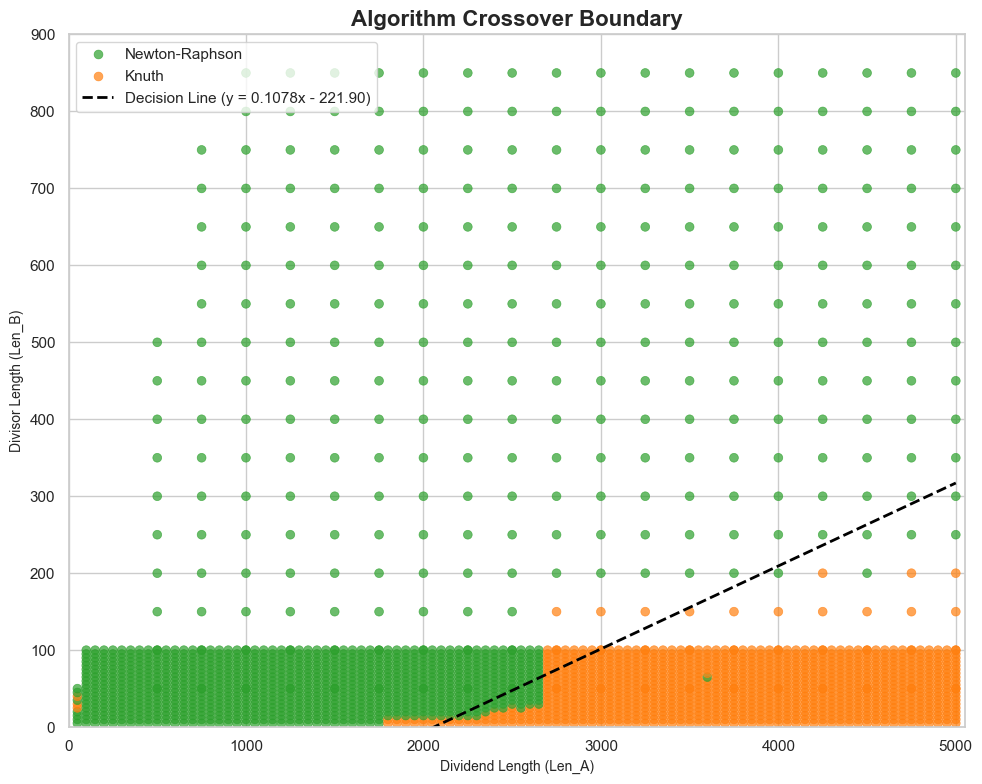

In [ ]:
# Clean global style
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {"figure.autolayout": True, "axes.titlesize": 12, "axes.labelsize": 10}
)

plt.figure(figsize=(10, 8))

# Plot the actual benchmark wins
sns.scatterplot(
    data=df,
    x="Len_A",
    y="Len_B",
    hue="Fastest_Algorithm",
    palette={"Knuth": "#ff7f0e", "Newton-Raphson": "#2ca02c"},
    alpha=0.7,
    s=40,
    edgecolor=None,
)

# Generate points for the boundary line
x_vals = np.array([df["Len_A"].min(), df["Len_A"].max()])
y_vals = m * x_vals + c

# Plot the learned boundary line
plt.plot(
    x_vals,
    y_vals,
    "--",
    color="black",
    linewidth=2,
    label=f"Decision Line (y = {m:.4f}x {'+' if c > 0 else '-'} {abs(c):.2f})",
)

# Restrict axes to actual data ranges (prevents the line from stretching to infinity)
plt.xlim(df["Len_A"].min() - 50, df["Len_A"].max() + 50)
plt.ylim(0, df["Len_B"].max() + 50)

plt.title("Algorithm Crossover Boundary", fontsize=16, fontweight="bold")
plt.xlabel("Dividend Length (Len_A)")
plt.ylabel("Divisor Length (Len_B)")
plt.legend(loc="upper left")
plt.show()

## Complexity Curves

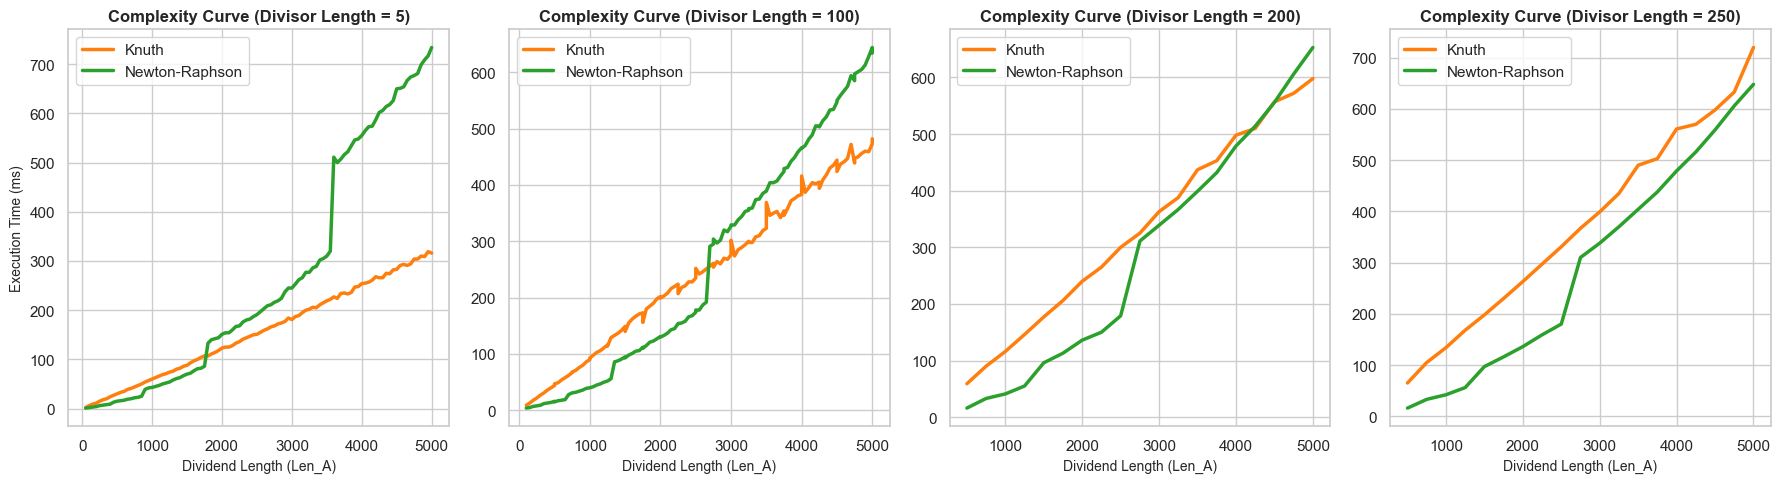

In [ ]:
# Specific divisor lengths to slice
slice_targets = [5, 100, 200, 250]

fig, axes = plt.subplots(1, len(slice_targets), figsize=(18, 5), sharey=False)

for i, target_b in enumerate(slice_targets):
    # Filter the dataframe for the specific slice
    slice_df = df[df["Len_B"] == target_b].sort_values(by="Len_A")

    if slice_df.empty:
        axes[i].set_title(f"No data for Len_B = {target_b}")
        continue

    axes[i].plot(
        slice_df["Len_A"],
        slice_df["Knuth_ms"],
        color="#ff7f0e",
        linewidth=2.5,
        label="Knuth",
    )
    axes[i].plot(
        slice_df["Len_A"],
        slice_df["NR_ms"],
        color="#2ca02c",
        linewidth=2.5,
        label="Newton-Raphson",
    )

    axes[i].set_title(
        f"Complexity Curve (Divisor Length = {target_b})", fontweight="bold"
    )
    axes[i].set_xlabel("Dividend Length (Len_A)")
    if i == 0:
        axes[i].set_ylabel("Execution Time (ms)")
    axes[i].legend()

plt.tight_layout()
plt.show()